In [1]:
import pandas as pd
import pandas as pd
import torch
import torch.nn as nn

In [2]:
df = pd.read_csv("powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [3]:
x = df.drop("PE", axis=1).values
y = df["PE"].values
x.shape, y.shape

((9568, 4), (9568,))

In [4]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((7654, 4), (7654,), (1914, 4), (1914,))

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

x_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

In [6]:
# Convert to PyTorch tensors

x_train_tensor = torch.tensor(x_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

x_test_tensor = torch.tensor(x_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

y_train_tensor, y_train

(tensor([[442.7500],
         [432.5200],
         [428.8000],
         ...,
         [464.2600],
         [440.4500],
         [484.4400]]),
 array([442.75, 432.52, 428.8 , ..., 464.26, 440.45, 484.44], shape=(7654,)))

In [7]:
# DATAset and DataLoader
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)
 
train_loader, test_loader

(<torch.utils.data.dataloader.DataLoader at 0x144345bf230>,
 <torch.utils.data.dataloader.DataLoader at 0x144346d0690>)

In [8]:
# build the model
class ANNRegressor(nn.Module):
    def __init__(self):
        super(ANNRegressor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, 1)    
        )

    def forward(self, x):
        return self.model(x)
    
model = ANNRegressor()


Epoch [10/100] Train Loss: 18.1900 Val Loss: 16.6665
Epoch [20/100] Train Loss: 18.1692 Val Loss: 17.4718
Epoch [30/100] Train Loss: 19.0379 Val Loss: 17.0523
Epoch [40/100] Train Loss: 17.9484 Val Loss: 17.5152
Epoch [50/100] Train Loss: 17.8055 Val Loss: 17.1840
Epoch [60/100] Train Loss: 18.6441 Val Loss: 16.2383
Epoch [70/100] Train Loss: 18.2000 Val Loss: 21.7647
Epoch [80/100] Train Loss: 17.7944 Val Loss: 16.4229
Epoch [90/100] Train Loss: 18.1924 Val Loss: 17.6092
Epoch [100/100] Train Loss: 18.1583 Val Loss: 16.4912


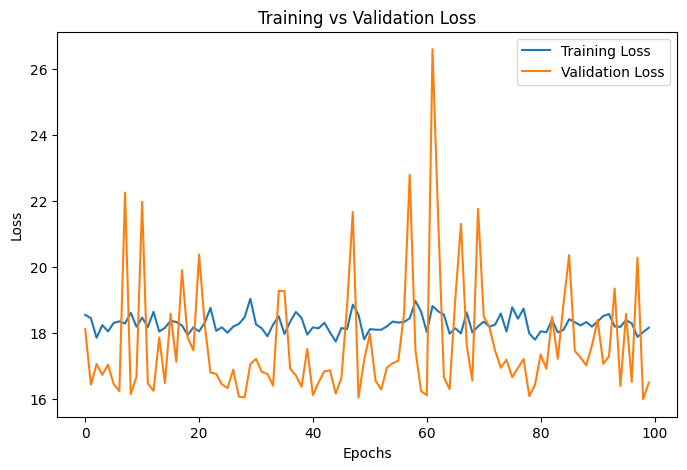

In [10]:
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

best_val_loss = float("inf")
train_losses = []
val_losses = []

num_epochs = 100

for epoch in range(num_epochs):


    model.train()
    running_loss = 0.0

    for xb, by in train_loader:

        pred = model(xb)
        loss = criterion(pred, by)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Average train loss
    running_loss /= len(train_loader)
    train_losses.append(running_loss)


    model.eval()
    validation_loss = 0.0

    with torch.no_grad():
        for xb, by in test_loader:

            pred = model(xb)
            loss = criterion(pred, by)

            validation_loss += loss.item()

    # Average validation loss
    validation_loss /= len(test_loader)
    val_losses.append(validation_loss)

    # Print every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {running_loss:.4f} "
              f"Val Loss: {validation_loss:.4f}")



loss_df = pd.DataFrame({
    "train_loss": train_losses,
    "validation_loss": val_losses
})

if best_val_loss > validation_loss:
    best_val_loss = validation_loss
    torch.save(model.state_dict(), "best_model.pth")


plt.figure(figsize=(8,5))

plt.plot(loss_df["train_loss"], label="Training Loss")
plt.plot(loss_df["validation_loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [11]:
# load best model
best_model = ANNRegressor()
best_model.load_state_dict(torch.load("best_model.pth"))
best_model.eval()


ANNRegressor(
  (model): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [12]:
# evaluate on test set
test_loss = 0.0
with torch.no_grad():
    for xb, by in test_loader:
        pred = best_model(xb)
        loss = criterion(pred, by)
        test_loss += loss.item()

test_loss /= len(test_loader)
print(f"Test Loss: {test_loss:.4f}")


Test Loss: 16.4912


In [13]:
pred_df = pd.DataFrame({
    "predictions": pred.squeeze().numpy(),
    "actual": by.squeeze().numpy()
})

pred_df.head()

,predictions,actual
0,466.603607,470.739990
1,460.672485,461.890015
2,470.024963,465.359985
3,435.332062,440.279999
4,457.795959,451.079987
